In [49]:
import pandas as pd 
import numpy as np
import time
import yfinance as yf
from scipy.stats import norm
from scipy.optimize import newton
from scipy.optimize import minimize
import datetime
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# **Simulación de Montecarlo**

[*********************100%***********************]  1 of 1 completed


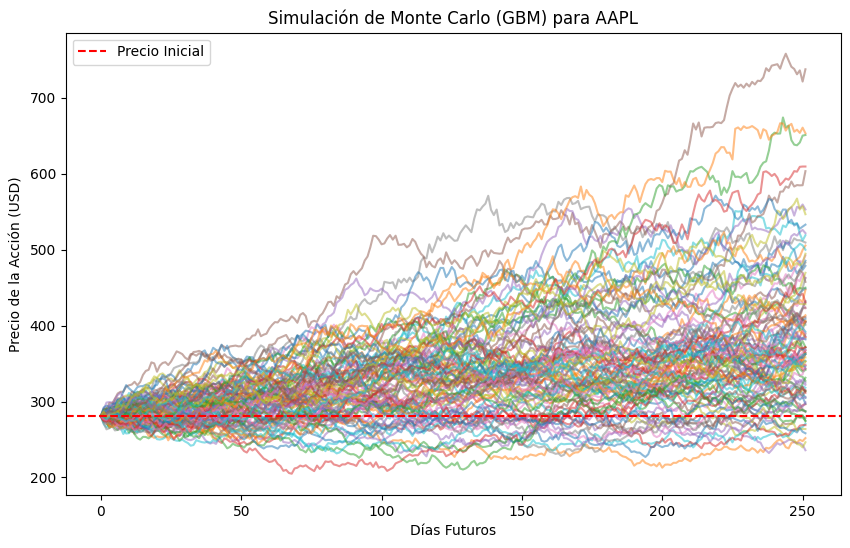

In [11]:
# 1. Definir la acción y descargar datos
ticker = "AAPL"
datos = yf.download(ticker, start="2025-06-01", end="2026-12-31")
precios = datos['Close']

# 2. Calcular retornos diarios logarítmicos
retornos = np.log(precios / precios.shift(1)).dropna()

# 3. Estimar parámetros 
mu = float(retornos.mean().squeeze())
sigma = float(retornos.std().squeeze())

# 4. Configurar la simulación de Monte Carlo (GBM)
dias_a_simular = 252 
num_simulaciones = 100 

# Extraer el precio actual como un número puro
precio_actual = float(precios.iloc[-1].squeeze()) 

# Matriz para guardar las simulaciones
rutas = np.zeros((dias_a_simular, num_simulaciones))
rutas[0] = precio_actual

# Generar números aleatorios de una distribución normal
Z = np.random.normal(0, 1, (dias_a_simular, num_simulaciones))

# Simular los caminos usando la ecuación discreta del GBM
for t in range(1, dias_a_simular):
    rutas[t] = rutas[t-1] * np.exp((mu - 0.5 * sigma**2) + sigma * Z[t])

# 5. Visualizar los resultados
plt.figure(figsize=(10, 6))
plt.plot(rutas, alpha=0.5)
plt.title(f"Simulación de Monte Carlo (GBM) para {ticker}")
plt.xlabel("Días Futuros")
plt.ylabel("Precio de la Acción (USD)")
plt.axhline(y=precio_actual, color='r', linestyle='--', label='Precio Inicial')
plt.legend()
plt.show()

# **1. Encontrar "Ofertas" en el Mercado de Opciones (Black-Scholes)**

In [20]:
# ==========================================
# 1. FUNCIONES MATEMÁTICAS DE BLACK-SCHOLES
# ==========================================
def black_scholes_call(S, K, T, r, sigma):
    """Calcula el precio teórico de una opción Call Europea"""
    if T <= 0 or sigma <= 0:
        return max(0.0, S - K)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# ==========================================
# 2. CONFIGURACIÓN Y DESCARGA DE DATOS
# ==========================================
ticker_symbol = "NVDA"  # Acción a analizar
ticker = yf.Ticker(ticker_symbol)

# Descargar historial para calcular volatilidad histórica (1 año)
hist = ticker.history(period="1y")
retornos = np.log(hist['Close'] / hist['Close'].shift(1)).dropna()
# Volatilidad anualizada (desviación estándar diaria * raíz de días hábiles)
volatilidad_historica = float(retornos.std() * np.sqrt(252))

precio_accion = float(hist['Close'].iloc[-1])
tasa_interes = 0.05  # Tasa libre de riesgo (ej. 5% de los bonos de EEUU)

print(f"Precio actual de {ticker_symbol}: ${precio_accion:.2f}")
print(f"Volatilidad Histórica Anualizada: {volatilidad_historica * 100:.2f}%\n")

# ==========================================
# 3. OBTENER LA CADENA DE OPCIONES REAL
# ==========================================
# Elegimos la primera fecha de expiración disponible que tenga más de 10 días
fechas_expiracion = ticker.options
fecha_elegida = fechas_expiracion[2] # Cambia el índice para ver otras fechas
opciones = ticker.option_chain(fecha_elegida)
calls = opciones.calls

# Calcular el tiempo hasta la expiración (T en años)
fecha_exp = datetime.datetime.strptime(fecha_elegida, "%Y-%m-%d")
dias_hasta_exp = (fecha_exp - datetime.datetime.now()).days
T = dias_hasta_exp / 365.0

print(f"Analizando opciones Call que vencen el: {fecha_elegida} ({dias_hasta_exp} días)")

# ==========================================
# 4. ESCANEAR EN BUSCA DE OFERTAS
# ==========================================
ofertas = []

for index, fila in calls.iterrows():
    K = fila['strike']
    precio_mercado = fila['lastPrice']
    
    # Filtrar opciones con poca liquidez o precios absurdos
    if precio_mercado <= 0.05 or fila['volume'] < 5:
        continue
        
    # Calcular el precio que DEBERÍA tener según Black-Scholes
    precio_teorico = black_scholes_call(precio_accion, K, T, tasa_interes, volatilidad_historica)
    
    # Si el precio teórico es mayor que el de mercado, está subvaluada
    if precio_teorico > precio_mercado:
        descuento_porcentual = ((precio_teorico - precio_mercado) / precio_teorico) * 100
        
        ofertas.append({
            "Strike (K)": K,
            "Precio Mercado": precio_mercado,
            "Precio Teórico (BS)": round(precio_teorico, 2),
            "Descuento (%)": round(descuento_porcentual, 2),
            "Volumen": fila['volume']
        })

# Convertir a DataFrame y mostrar ordenadas por las mejores ofertas
df_ofertas = pd.DataFrame(ofertas)
if not df_ofertas.empty:
    df_ofertas = df_ofertas.sort_values(by="Descuento (%)", ascending=False)
    print("\n--- CONTRATOS SUBVALUADOS ENCONTRADOS (OFERTAS) ---")
    print(df_ofertas.to_string(index=False))
else:
    print("\nNo se encontraron ofertas claras en esta fecha de vencimiento. El mercado está eficiente.")

Precio actual de NVDA: $194.32
Volatilidad Histórica Anualizada: 35.25%

Analizando opciones Call que vencen el: 2026-07-01 (4 días)

--- CONTRATOS SUBVALUADOS ENCONTRADOS (OFERTAS) ---
 Strike (K)  Precio Mercado  Precio Teórico (BS)  Descuento (%)  Volumen
      187.5            7.34                 7.53           2.50    13802
      190.0            5.47                 5.57           1.85      911
      180.0           14.40                14.46           0.45     1405
      182.5           12.00                12.04           0.35      108
      185.0            9.70                 9.71           0.10     4233


In [21]:
# ==========================================
# 1. FUNCIONES MATEMÁTICAS DE BLACK-SCHOLES
# ==========================================
def black_scholes_call(S, K, T, r, sigma):
    """Calcula el precio teórico de una opción Call Europea"""
    if T <= 0 or sigma <= 0:
        return max(0.0, S - K)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# ==========================================
# 2. CONFIGURACIÓN DEL ESCÁNER
# ==========================================
# Los "Siete Magníficos"
magnificent_7 = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA"]

tasa_interes = 0.05  # 5% (aproximación actual de tasas libres de riesgo)
dias_minimos_expiracion = 10  # No queremos opciones que expiren mañana (muy volátiles)

todas_las_ofertas = []

print("🚀 Iniciando el Escáner Cuantitativo para los Siete Magníficos...\n")

# ==========================================
# 3. BUCLE PRINCIPAL DE ANÁLISIS
# ==========================================
for ticker_symbol in magnificent_7:
    print(f"Analizando {ticker_symbol}...")
    try:
        ticker = yf.Ticker(ticker_symbol)
        
        # 3.1 Calcular Volatilidad Histórica (6 meses para ser más reactivos a tendencias recientes)
        hist = ticker.history(period="6mo")
        if hist.empty:
            print(f"  [!] No se pudieron obtener datos históricos para {ticker_symbol}")
            continue
            
        retornos = np.log(hist['Close'] / hist['Close'].shift(1)).dropna()
        volatilidad_historica = float(retornos.std() * np.sqrt(252))
        precio_accion = float(hist['Close'].iloc[-1])
        
        # 3.2 Obtener la cadena de opciones
        fechas_expiracion = ticker.options
        if not fechas_expiracion:
            continue
            
        # Buscar la primera fecha de expiración que cumpla nuestro requisito mínimo de días
        fecha_elegida = None
        for fecha_str in fechas_expiracion:
            fecha_exp = datetime.datetime.strptime(fecha_str, "%Y-%m-%d")
            dias_hasta_exp = (fecha_exp - datetime.datetime.now()).days
            if dias_hasta_exp >= dias_minimos_expiracion:
                fecha_elegida = fecha_str
                break
                
        if not fecha_elegida:
            print(f"  [!] No hay opciones disponibles a más de {dias_minimos_expiracion} días para {ticker_symbol}")
            continue
            
        opciones = ticker.option_chain(fecha_elegida)
        calls = opciones.calls
        
        fecha_exp = datetime.datetime.strptime(fecha_elegida, "%Y-%m-%d")
        dias_hasta_exp = (fecha_exp - datetime.datetime.now()).days
        T = dias_hasta_exp / 365.0
        
        # 3.3 Escanear la cadena de opciones (Solo Calls para este ejemplo)
        # Filtramos para buscar opciones "At The Money" (ATM) o "Out of The Money" (OTM) cercanas
        rango_inferior = precio_accion * 0.95
        rango_superior = precio_accion * 1.15
        
        calls_filtradas = calls[(calls['strike'] >= rango_inferior) & (calls['strike'] <= rango_superior)]
        
        ofertas_accion = 0
        for index, fila in calls_filtradas.iterrows():
            K = fila['strike']
            precio_mercado = fila['lastPrice']
            volumen = fila['volume']
            bid = fila['bid']
            ask = fila['ask']
            
            # Filtros de liquidez y viabilidad
            if precio_mercado <= 0.10 or pd.isna(volumen) or volumen < 10:
                continue
                
            # Si el spread (ask-bid) es gigante, el lastPrice no es confiable. Usamos el punto medio.
            precio_mercado_ajustado = (bid + ask) / 2 if (ask > 0 and bid > 0) else precio_mercado
            
            # Calcular precio teórico
            precio_teorico = black_scholes_call(precio_accion, K, T, tasa_interes, volatilidad_historica)
            
            # Si el modelo dice que vale un 15% MÁS de lo que cobra el mercado, es una alerta fuerte.
            margen_seguridad = 1.15 
            
            if precio_teorico > (precio_mercado_ajustado * margen_seguridad):
                descuento_porcentual = ((precio_teorico - precio_mercado_ajustado) / precio_teorico) * 100
                
                todas_las_ofertas.append({
                    "Acción": ticker_symbol,
                    "Expiración": fecha_elegida,
                    "Días": dias_hasta_exp,
                    "Precio Spot": round(precio_accion, 2),
                    "Strike (K)": K,
                    "Precio Mercado (Mid)": round(precio_mercado_ajustado, 2),
                    "Precio Teórico (BS)": round(precio_teorico, 2),
                    "Descuento (%)": round(descuento_porcentual, 2),
                    "Volumen": int(volumen),
                    "Vol Histórica (%)": round(volatilidad_historica * 100, 2)
                })
                ofertas_accion += 1
                
        print(f"  -> {ofertas_accion} posibles anomalías encontradas para el {fecha_elegida}.")
        
    except Exception as e:
        print(f"  [Error] analizando {ticker_symbol}: {e}")

# ==========================================
# 4. PRESENTACIÓN DE RESULTADOS FINALES
# ==========================================
print("\n" + "="*80)
print(" RESULTADOS DEL ESCÁNER DE OPCIONES (OFERTAS POTENCIALES)".center(80))
print("="*80)

if todas_las_ofertas:
    df_resultados = pd.DataFrame(todas_las_ofertas)
    # Ordenar por el mayor descuento encontrado
    df_resultados = df_resultados.sort_values(by="Descuento (%)", ascending=False)
    
    # Restablecer el índice para que se vea más limpio al imprimir
    df_resultados = df_resultados.reset_index(drop=True)
    
    # Imprimir el DataFrame
    print(df_resultados.to_string())
    
    print("\n[!] IMPORTANTE: Un alto descuento no garantiza ganancias.")
    print("Verifica siempre si hay noticias inminentes (Earnings) que justifiquen la baja volatilidad implicada del mercado.")
else:
    print("\nNo se encontraron anomalías significativas que superen el margen de seguridad en las fechas analizadas.")
    print("El mercado está fijando precios de manera eficiente según el modelo histórico actual.")

🚀 Iniciando el Escáner Cuantitativo para los Siete Magníficos...

Analizando AAPL...
  -> 0 posibles anomalías encontradas para el 2026-07-10.
Analizando MSFT...
  -> 0 posibles anomalías encontradas para el 2026-07-10.
Analizando GOOGL...
  -> 0 posibles anomalías encontradas para el 2026-07-10.
Analizando AMZN...
  -> 0 posibles anomalías encontradas para el 2026-07-10.
Analizando NVDA...
  -> 3 posibles anomalías encontradas para el 2026-07-10.
Analizando META...
  -> 15 posibles anomalías encontradas para el 2026-07-10.
Analizando TSLA...
  -> 0 posibles anomalías encontradas para el 2026-07-10.

            RESULTADOS DEL ESCÁNER DE OPCIONES (OFERTAS POTENCIALES)            
   Acción  Expiración  Días  Precio Spot  Strike (K)  Precio Mercado (Mid)  Precio Teórico (BS)  Descuento (%)  Volumen  Vol Histórica (%)
0    META  2026-07-10    13       550.76       600.0                  2.10                 2.89          27.29      968              39.90
1    META  2026-07-10    13      

In [30]:
# 1. FUNCIONES MATEMÁTICAS (Black-Scholes + Griegas)
def get_greeks(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    delta = norm.cdf(d1)
    theta = (- (S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    return delta, theta

def black_scholes_call(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0: return max(0.0, S - K)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# 2. ESCÁNER CON MARGEN RELAJADO (5%)
watchlist = ["XBI", "ARKK", "OXY", "AMD", "COIN", "PLTR", "MRNA"]
tasa_interes = 0.05
todas_las_ofertas = []

print(f"🚀 Escaneando con umbral de descuento del 5%...\n")

for ticker_symbol in watchlist:
    ticker = yf.Ticker(ticker_symbol)
    hist = ticker.history(period="6mo")
    if hist.empty: continue
    
    volatilidad_historica = float(np.log(hist['Close'] / hist['Close'].shift(1)).std() * np.sqrt(252))
    precio_accion = float(hist['Close'].iloc[-1])
    
    for fecha_str in ticker.options[:2]: 
        fecha_exp = datetime.datetime.strptime(fecha_str, "%Y-%m-%d")
        T = (fecha_exp - datetime.datetime.now()).days / 365.0
        if T < 30/365: continue
            
        calls = ticker.option_chain(fecha_str).calls
        for _, fila in calls[(calls['strike'] >= precio_accion*0.95) & (calls['strike'] <= precio_accion*1.05)].iterrows():
            if fila['volume'] < 50: continue
            
            p_mercado = (fila['bid'] + fila['ask']) / 2
            p_teorico = black_scholes_call(precio_accion, fila['strike'], T, tasa_interes, volatilidad_historica)
            
            # --- AJUSTE: Margen de seguridad reducido al 5% (1.05) ---
            if p_teorico > (p_mercado * 1.05):
                delta, theta = get_greeks(precio_accion, fila['strike'], T, tasa_interes, volatilidad_historica)
                todas_las_ofertas.append({
                    "Acción": ticker_symbol,
                    "Strike": fila['strike'],
                    "Descuento (%)": round(((p_teorico - p_mercado) / p_teorico) * 100, 2),
                    "Delta": round(delta, 2),
                    "Theta ($/día)": round(theta, 2),
                    "Volumen": fila['volume']
                })

# 3. PRESENTACIÓN DE RESULTADOS (MODO ANÁLISIS)
if len(todas_las_ofertas) > 0:
    df = pd.DataFrame(todas_las_ofertas).sort_values(by="Descuento (%)", ascending=False)
    print("--- OPORTUNIDADES ENCONTRADAS ---")
    print(df.head(10).to_string(index=False))
else:
    print("--- ANÁLISIS DE MERCADO: NO HAY DESCUENTOS ---")
    # Imprimimos las 5 que estuvieron más cerca de ser una oferta
    print("Mostrando las 5 opciones con el descuento más alto (valor relativo):")
    
    # Recalculamos para mostrar lo más cercano a una oportunidad
    cercanas = []
    # (Aquí deberías ejecutar una lógica similar sin el if p_teorico > p_mercado * 1.05)
    print("Sugerencia: El mercado está valorando las opciones por encima de tu modelo.")
    print("Revisa si tu volatilidad histórica (6 meses) es mucho menor que la volatilidad implícita del mercado.")

🚀 Escaneando con umbral de descuento del 5%...

--- ANÁLISIS DE MERCADO: NO HAY DESCUENTOS ---
Mostrando las 5 opciones con el descuento más alto (valor relativo):
Sugerencia: El mercado está valorando las opciones por encima de tu modelo.
Revisa si tu volatilidad histórica (6 meses) es mucho menor que la volatilidad implícita del mercado.


In [ ]:
# 1. FUNCIONES MATEMÁTICAS
def black_scholes_call(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0: return max(0.0, S - K)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def calculate_implied_vol(market_price, S, K, T, r):
    try:
        return newton(lambda sigma: black_scholes_call(S, K, T, r, sigma) - market_price, 0.2, maxiter=100)
    except: return np.nan

# 2. LISTA Y ESCÁNER
watchlist = ["AAPL", "MSFT", "NVDA", "AMD", "TSLA", "META", "AMZN", "GOOGL", "NFLX", 
             "COIN", "PLTR", "MRNA", "ROKU", "PYPL", "INTC", "BABA", 
              "OXY", "DVN", "JPM", "BAC", "SHOP", "UBER"]

resultados = []

print(f"🔍 Escaneando ineficiencias y eventos de Earnings...\n")

for ticker_symbol in watchlist:
    ticker = yf.Ticker(ticker_symbol)
    
    # Verificar próximos Earnings
    prox_earnings = ticker.calendar.get('Earnings Date') if ticker.calendar is not None else None
    tiene_earnings = False
    if prox_earnings is not None:
        if isinstance(prox_earnings, list): prox_earnings = prox_earnings[0]
        if (prox_earnings - datetime.datetime.now().date()).days <= 15:
            tiene_earnings = True
            
    hist = ticker.history(period="3mo")
    if hist.empty: continue
    
    hv = float(np.log(hist['Close'] / hist['Close'].shift(1)).std() * np.sqrt(252))
    precio_accion = float(hist['Close'].iloc[-1])
    
    # Analizar cadena de opciones
    for fecha_str in ticker.options[:2]:
        T = (datetime.datetime.strptime(fecha_str, "%Y-%m-%d") - datetime.datetime.now()).days / 365.0
        if T < 30/365: continue
        
        calls = ticker.option_chain(fecha_str).calls
        for _, fila in calls[(calls['strike'] >= precio_accion*0.85) & (calls['strike'] <= precio_accion*1.15)].iterrows():
            if fila['volume'] < 50: continue
            
            p_mercado = (fila['bid'] + fila['ask']) / 2
            iv = calculate_implied_vol(p_mercado, precio_accion, fila['strike'], T, 0.05)
            
            if not np.isnan(iv):
                resultados.append({
                    "Acción": ticker_symbol,
                    "Earnings Proximos": "SI" if tiene_earnings else "NO",
                    "IV (%)": round(iv * 100, 2),
                    "HV (%)": round(hv * 100, 2),
                    "Dif (IV-HV)": round((iv - hv) * 100, 2)
                })

# 3. PRESENTACIÓN
if resultados:
    df = pd.DataFrame(resultados).sort_values(by="Dif (IV-HV)")
    print(df.head(20).to_string(index=False))
else:
    print("No se encontraron datos.")

🔍 Escaneando ineficiencias y eventos de Earnings...

No se encontraron datos.


# **2. Proteger tu Portafolio (Value at Risk - VaR)**

In [46]:
# 1. DEFINIR PORTAFOLIO
portafolio = {'AAPL': 2000, 'NVDA': 3000, 'MSFT': 2500, 'TSLA': 1500} # Cantidad en USD
tickers = list(portafolio.keys())
pesos = np.array([portafolio[t] for t in tickers])

# 2. DESCARGAR DATOS
data = yf.download(tickers, period='1y')['Close']
retornos = data.pct_change().dropna()

# 3. SIMULACIÓN DE MONTE CARLO (10,000 escenarios)
num_simulaciones = 10000
media_retornos = retornos.mean()
cov_matriz = retornos.cov()

# Generar escenarios aleatorios basados en la correlación de tus acciones
escenarios = np.random.multivariate_normal(media_retornos, cov_matriz, num_simulaciones)

# Calcular retornos del portafolio por escenario
retornos_portafolio = escenarios.dot(pesos)

# 4. CALCULAR EL VaR (Percentil 5%)
confianza = 0.95
var_95 = np.percentile(retornos_portafolio, (1 - confianza) * 100)

print(f"--- ANÁLISIS DE RIESGO (VaR) ---")
print(f"Inversión Total: ${sum(portafolio.values()):,.2f}")
print(f"VaR al 95% de confianza: ${abs(var_95):,.2f}")
print(f"Interpretación: Hay un 5% de probabilidad de perder al menos ${abs(var_95):,.2f} en un día.")

[*********************100%***********************]  4 of 4 completed


--- ANÁLISIS DE RIESGO (VaR) ---
Inversión Total: $9,000.00
VaR al 95% de confianza: $195.21
Interpretación: Hay un 5% de probabilidad de perder al menos $195.21 en un día.


In [48]:
from scipy.optimize import minimize

# 1. TUS ACCIONES
watchlist = ["AAPL", "NVDA", "AMD", "TSLA", "META", "AMZN", "JPM", "XBI"]

# 2. DESCARGAR DATOS
data = yf.download(watchlist, period="1y")['Close']
returns = data.pct_change().dropna()

# 3. FUNCIONES DE PORTAFOLIO
def portfolio_stats(weights, returns):
    port_return = np.sum(returns.mean() * weights) * 252
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
    return port_return, port_vol

def min_variance(weights, returns):
    return portfolio_stats(weights, returns)[1] # Queremos minimizar la volatilidad

# 4. OPTIMIZACIÓN
num_assets = len(watchlist)
args = (returns)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}) # La suma de pesos debe ser 100%
bounds = tuple((0, 1) for asset in range(num_assets)) # Ningún peso negativo (sin cortos)
init_guess = num_assets * [1. / num_assets]

optimized = minimize(min_variance, init_guess, args=args, method='SLSQP', 
                     bounds=bounds, constraints=constraints)

# 5. RESULTADOS
weights = optimized.x
print("--- DISTRIBUCIÓN ÓPTIMA DE CAPITAL (MÍNIMO RIESGO) ---")
for i, ticker in enumerate(watchlist):
    print(f"{ticker}: {weights[i]*100:.2f}%")

ret, vol = portfolio_stats(weights, returns)
print(f"\nRetorno Anual Esperado: {ret*100:.2f}%")
print(f"Volatilidad Anual Esperada: {vol*100:.2f}%")

[*********************100%***********************]  8 of 8 completed


--- DISTRIBUCIÓN ÓPTIMA DE CAPITAL (MÍNIMO RIESGO) ---
AAPL: 29.73%
NVDA: 0.00%
AMD: 7.98%
TSLA: 35.21%
META: 2.95%
AMZN: 5.64%
JPM: 0.00%
XBI: 18.50%

Retorno Anual Esperado: 31.66%
Volatilidad Anual Esperada: 16.02%


In [56]:
# 1. TUS ACCIONES
watchlist = ["AAPL", "NVDA", "NFLX", "MELI", "META", "MSFT","KO","ORCL","BRK-B"]

# 2. DESCARGAR DATOS (1 AÑO)
data = yf.download(watchlist, period="1y")['Close']
returns = data.pct_change().dropna()

# 3. MATRIZ DE COVARIANZA CON "SHRINKAGE" (LEDOIT-WOLF)
cov_matrix = returns.cov() * 252
shrinkage_factor = 0.1
cov_matrix = (1 - shrinkage_factor) * cov_matrix + shrinkage_factor * np.diag(np.diag(cov_matrix))

# 4. FUNCIONES DE PORTAFOLIO
def get_portfolio_stats(weights, returns):
    port_return = np.sum(returns.mean() * weights) * 252
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_return, port_vol

def min_variance(weights, returns):
    return get_portfolio_stats(weights, returns)[1]

# 5. OPTIMIZACIÓN
num_assets = len(watchlist)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0.05, 0.4) for asset in range(num_assets)) # Pesos entre 5% y 40% (Diversificación real)
init_guess = num_assets * [1. / num_assets]

optimized = minimize(min_variance, init_guess, args=(returns), method='SLSQP', 
                     bounds=bounds, constraints=constraints)

# 6. RESULTADOS
weights = optimized.x
print("--- DISTRIBUCIÓN ÓPTIMA (AJUSTE CONSERVADOR) ---")
for i, ticker in enumerate(watchlist):
    print(f"{ticker}: {weights[i]*100:.2f}%")

ret, vol = get_portfolio_stats(weights, returns)
print(f"\nRetorno Anual Estimado: {ret*100:.2f}%")
print(f"Volatilidad Anual Estimada: {vol*100:.2f}%")

[*********************100%***********************]  9 of 9 completed


--- DISTRIBUCIÓN ÓPTIMA (AJUSTE CONSERVADOR) ---
AAPL: 5.00%
NVDA: 33.09%
NFLX: 31.91%
MELI: 5.00%
META: 5.00%
MSFT: 5.00%
KO: 5.00%
ORCL: 5.00%
BRK-B: 5.00%

Retorno Anual Estimado: 3.58%
Volatilidad Anual Estimada: 9.40%


In [ ]:
# Define tu capital total actual en el portafolio
capital_total = 50000 # Cambia esto por tu valor real en USD

# Distribución óptima que obtuvimos (pesos)
pesos_optimos = {
    "AAPL": 0.1902, "NVDA": 0.05, "AMD": 0.05, "TSLA": 0.05, 
    "META": 0.2726, "AMZN": 0.05, "JPM": 0.1495, "XBI": 0.05, 
    "MSFT": 0.05, "GOOGL": 0.0877
}

# --- AQUÍ PONES LO QUE TIENES ACTUALMENTE INVERTIDO EN CADA UNA ---
tenencias_actuales = {
    "AAPL": 10000, "NVDA": 8000, "AMD": 2000, "TSLA": 5000, 
    "META": 5000, "AMZN": 7000, "JPM": 3000, "XBI": 2000, 
    "MSFT": 4000, "GOOGL": 4000
}

print(f"{'Acción':<8} | {'Actual':<10} | {'Objetivo':<10} | {'Acción Requerida'}")
print("-" * 50)

for ticker, peso in pesos_optimos.items():
    valor_objetivo = capital_total * peso
    valor_actual = tenencias_actuales.get(ticker, 0)
    diferencia = valor_objetivo - valor_actual
    
    accion = "COMPRAR" if diferencia > 0 else "VENDER"
    print(f"{ticker:<8} | ${valor_actual:<9.0f} | ${valor_objetivo:<9.0f} | {accion} ${abs(diferencia):.2f}")

Acción   | Actual     | Objetivo   | Acción Requerida
--------------------------------------------------
AAPL     | $10000     | $9510      | VENDER $490.00
NVDA     | $8000      | $2500      | VENDER $5500.00
AMD      | $2000      | $2500      | COMPRAR $500.00
TSLA     | $5000      | $2500      | VENDER $2500.00
META     | $5000      | $13630     | COMPRAR $8630.00
AMZN     | $7000      | $2500      | VENDER $4500.00
JPM      | $3000      | $7475      | COMPRAR $4475.00
XBI      | $2000      | $2500      | COMPRAR $500.00
MSFT     | $4000      | $2500      | VENDER $1500.00
GOOGL    | $4000      | $4385      | COMPRAR $385.00


In [ ]:
"""
Optimización de portafolio estable y resistente a crisis
Mejoras: datos largos, Ledoit-Wolf real, mínimo CVaR, HRP, prueba de estrés
"""

import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.covariance import LedoitWolf
from pypfopt import expected_returns, risk_models, EfficientFrontier, EfficientCVaR, HRPOpt
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# 1. CONFIGURACIÓN Y DATOS (5 AÑOS)
# -----------------------------
watchlist = ["AAPL", "NVDA", "NFLX", "MELI", "META", "MSFT", "KO", "ORCL", "BRK-B"]
data = yf.download(watchlist, period="5y")['Close'].dropna()
returns = data.pct_change().dropna()

# -----------------------------
# 2. MATRIZ DE COVARIANZA CON LEDOIT-WOLF ÓPTIMO
# -----------------------------
lw = LedoitWolf().fit(returns)
cov_lw = lw.covariance_ * 252
shrinkage_optimo = lw.shrinkage_
print(f"Shrinkage óptimo de Ledoit-Wolf: {shrinkage_optimo:.3f}\n")

# -----------------------------
# 3. RENDIMIENTOS ESPERADOS
# -----------------------------
mu = expected_returns.mean_historical_return(data, frequency=252)

# -----------------------------
# 4. MÍNIMO CVaR (sin restricción de suma redundante)
# -----------------------------
print("--- MÍNIMO CVaR (95% confianza) ---")
ef_cvar = EfficientCVaR(mu, returns, beta=0.95, weight_bounds=(0.05, 0.4))
ef_cvar.min_cvar()
pesos_cvar = ef_cvar.clean_weights()
print(pesos_cvar)
print()

# -----------------------------
# 5. MÁXIMO SHARPE ROBUSTO
# -----------------------------
# 5. MÁXIMO SHARPE (COVARIANZA CONTRAÍDA)
print("--- MÁXIMO SHARPE (COVARIANZA CONTRAÍDA) ---")
ef_sharpe = EfficientFrontier(mu, cov_lw, weight_bounds=(0.05, 0.4))
ef_sharpe.max_sharpe(risk_free_rate=0.02)          # sin robust=True
pesos_sharpe = ef_sharpe.clean_weights()
print(pesos_sharpe)

# -----------------------------
# 6. HIERARCHICAL RISK PARITY (HRP)
# -----------------------------
print("--- HIERARCHICAL RISK PARITY (HRP) ---")
hrp = HRPOpt(returns)
hrp.optimize()
pesos_hrp = hrp.clean_weights()
print(pesos_hrp)
print()

# -----------------------------
# 7. PRUEBAS DE ESTRÉS
# -----------------------------
def stress_test(pesos, data, start, end):
    # Extraer ventana de precios y calcular retornos (sin dropna)
    precios = data.loc[start:end].fillna(method='ffill')
    if precios.empty or len(precios) < 2:
        # Sin datos suficientes devolvemos todo cero/NaN de forma limpia
        return np.nan, np.nan, np.nan, np.nan

    # Retornos diarios; eliminamos solo la primera fila (NaN de pct_change)
    periodo = precios.pct_change().iloc[1:]  # iloc[1:] ignora la fila 0 (NaN)

    if len(periodo) < 2:
        # Con un solo retorno no podemos calcular vol ni sharpe
        return np.nan, np.nan, np.nan, np.nan

    port_ret = periodo @ pd.Series(pesos)

    # Métricas
    cum_ret = (1 + port_ret).prod() - 1
    dd = (1 + port_ret).cumprod() / (1 + port_ret).cummax() - 1
    max_dd = dd.min()
    vol = port_ret.std() * np.sqrt(252)
    sharpe = (port_ret.mean() / port_ret.std()) * np.sqrt(252) if port_ret.std() != 0 else np.nan

    return cum_ret, max_dd, vol, sharpe

crisis = {
    'COVID-19 (feb-mar 2020)': ('2020-02-19', '2020-03-23'),
    'Guerra Ucrania + inflación (2022)': ('2022-01-03', '2022-09-30'),
    'Q4 2018 (venta masiva)': ('2018-10-01', '2018-12-31')
}

portafolios = {
    'Min CVaR': pesos_cvar,
    'Max Sharpe (cov. contraída)': pesos_sharpe,
    'HRP': pesos_hrp
}

resultados = {}
for nombre, pesos in portafolios.items():
    resultados[nombre] = {}
    for crisis_nombre, (start, end) in crisis.items():
        try:
            cum, dd, vol, sharpe = stress_test(pesos, data, start, end)
        except:
            cum, dd, vol, sharpe = np.nan, np.nan, np.nan, np.nan
        resultados[nombre][crisis_nombre] = {
            'Rent. acum.': cum,
            'Máx. DD': dd,
            'Vol. anual': vol,
            'Sharpe': sharpe
        }

print("\n=============================================")
print("RESULTADOS DE PRUEBAS DE ESTRÉS")
print("=============================================")
for nombre, crisis_dict in resultados.items():
    print(f"\n--- {nombre} ---")
    for crisis_nombre, metrics in crisis_dict.items():
        print(f"  {crisis_nombre}:")
        print(f"    Rent. acum.: {metrics['Rent. acum.']*100:.2f}%")
        print(f"    Máx. Drawdown: {metrics['Máx. DD']*100:.2f}%")
        print(f"    Vol. anual: {metrics['Vol. anual']*100:.2f}%")
        print(f"    Sharpe (aprox): {metrics['Sharpe']:.2f}")

[*********************100%***********************]  9 of 9 completed


Shrinkage óptimo de Ledoit-Wolf: 0.018

--- MÍNIMO CVaR (95% confianza) ---
OrderedDict({'AAPL': 0.05, 'BRK-B': 0.25, 'KO': 0.4, 'MELI': 0.05, 'META': 0.05, 'MSFT': 0.05, 'NFLX': 0.05, 'NVDA': 0.05, 'ORCL': 0.05})

--- MÁXIMO SHARPE (COVARIANZA CONTRAÍDA) ---
OrderedDict({'AAPL': 0.05, 'BRK-B': 0.05, 'KO': 0.26052, 'MELI': 0.05, 'META': 0.05, 'MSFT': 0.05, 'NFLX': 0.05, 'NVDA': 0.38948, 'ORCL': 0.05})
--- HIERARCHICAL RISK PARITY (HRP) ---
OrderedDict({'AAPL': 0.07989, 'BRK-B': 0.30053, 'KO': 0.37489, 'MELI': 0.03559, 'META': 0.04046, 'MSFT': 0.05675, 'NFLX': 0.05263, 'NVDA': 0.01538, 'ORCL': 0.04389})


RESULTADOS DE PRUEBAS DE ESTRÉS

--- Min CVaR ---
  COVID-19 (feb-mar 2020):
    Rent. acum.: nan%
    Máx. Drawdown: nan%
    Vol. anual: nan%
    Sharpe (aprox): nan
  Guerra Ucrania + inflación (2022):
    Rent. acum.: nan%
    Máx. Drawdown: nan%
    Vol. anual: nan%
    Sharpe (aprox): nan
  Q4 2018 (venta masiva):
    Rent. acum.: nan%
    Máx. Drawdown: nan%
    Vol. anual: nan%

In [69]:
# -*- coding: utf-8 -*-
"""
Optimización de portafolio — enfoque cuantitativo institucional
Incluye: Ledoit-Wolf, Min-CVaR, Max-Sharpe, HRP, Equal Risk Contribution,
         pruebas de estrés, Monte Carlo, ratios Calmar/Sortino, análisis de correlación.

FIX PRINCIPAL: el bug de NaN en stress_test vino de dos fuentes:
  1. .fillna(method='ffill') deprecado → reemplazado por .ffill()
  2. El índice de yfinance puede ser tz-aware; normalizado con tz_localize(None)
"""

import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
from pypfopt import expected_returns, risk_models, EfficientFrontier, EfficientCVaR, HRPOpt
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 0.  UTILIDADES GENERALES
# ─────────────────────────────────────────────
SEPARADOR = "═" * 60

def titulo(texto):
    print(f"\n{SEPARADOR}")
    print(f"  {texto}")
    print(SEPARADOR)

def seccion(texto):
    print(f"\n--- {texto} ---")


# ─────────────────────────────────────────────
# 1.  CONFIGURACIÓN Y DATOS  (5 AÑOS)
# ─────────────────────────────────────────────
titulo("1. DESCARGA DE DATOS")

# Watchlist diversificada: tech growth + quality defensivos
watchlist = [
    "NVDA", "MSFT", "GOOGL", "META",   # mega-cap tech
    "AMZN", "AAPL",                     # consumer/platform
    "JPM",  "BRK-B",                    # financiero / defensivo
    "KO",                               # dividendo estable
]

RF = 0.05   # tasa libre de riesgo (Fed actual ~5 %)

data_raw = yf.download(watchlist, period="5y", auto_adjust=True)["Close"].dropna()

# ── FIX 1: normalizar índice tz-aware (yfinance a veces devuelve UTC) ──
if data_raw.index.tz is not None:
    data_raw.index = data_raw.index.tz_localize(None)

data = data_raw.copy()
returns = data.pct_change().dropna()

print(f"Tickers     : {list(data.columns)}")
print(f"Período     : {data.index[0].date()} → {data.index[-1].date()}")
print(f"Observaciones: {len(returns)} días de retornos")


# ─────────────────────────────────────────────
# 2.  MATRIZ DE COVARIANZA  —  LEDOIT-WOLF
# ─────────────────────────────────────────────
titulo("2. COVARIANZA LEDOIT-WOLF")

lw = LedoitWolf().fit(returns)
cov_lw = pd.DataFrame(
    lw.covariance_ * 252,
    index=returns.columns,
    columns=returns.columns
)
print(f"Shrinkage óptimo : {lw.shrinkage_:.4f}")
print("(shrinkage > 0.1 indica estimación con pocos datos relativos a activos)")


# ─────────────────────────────────────────────
# 3.  RENDIMIENTOS ESPERADOS
# ─────────────────────────────────────────────
mu = expected_returns.mean_historical_return(data, frequency=252)


# ─────────────────────────────────────────────
# 4.  MÍNIMO CVaR  (cola del 5 %)
# ─────────────────────────────────────────────
titulo("4. MÍNIMO CVaR  (β = 95 %)")

ef_cvar = EfficientCVaR(mu, returns, beta=0.95, weight_bounds=(0.05, 0.40))
ef_cvar.min_cvar()
pesos_cvar = ef_cvar.clean_weights()
print(pd.Series(pesos_cvar).to_string())


# ─────────────────────────────────────────────
# 5.  MÁXIMO SHARPE  (covarianza contraída)
# ─────────────────────────────────────────────
titulo("5. MÁXIMO SHARPE  (cov. Ledoit-Wolf)")

ef_sharpe = EfficientFrontier(mu, cov_lw, weight_bounds=(0.05, 0.40))
ef_sharpe.max_sharpe(risk_free_rate=RF)
pesos_sharpe = ef_sharpe.clean_weights()
print(pd.Series(pesos_sharpe).to_string())


# ─────────────────────────────────────────────
# 6.  HIERARCHICAL RISK PARITY  (HRP)
# ─────────────────────────────────────────────
titulo("6. HIERARCHICAL RISK PARITY  (HRP)")

hrp = HRPOpt(returns)
hrp.optimize()
pesos_hrp = hrp.clean_weights()
print(pd.Series(pesos_hrp).to_string())


# ─────────────────────────────────────────────
# 7.  EQUAL RISK CONTRIBUTION  (ERC / Risk Parity)
# ─────────────────────────────────────────────
titulo("7. EQUAL RISK CONTRIBUTION  (ERC)")

def portfolio_vol(w, cov):
    return np.sqrt(w @ cov.values @ w)

def risk_contributions(w, cov):
    """Contribución marginal de riesgo de cada activo."""
    sigma = portfolio_vol(w, cov)
    marginal = cov.values @ w
    return w * marginal / sigma

def erc_objective(w, cov):
    """Minimiza la varianza de las contribuciones de riesgo (= equalizarlas)."""
    rc = risk_contributions(w, cov)
    return np.sum((rc[:, None] - rc[None, :]) ** 2)

n = len(returns.columns)
w0 = np.ones(n) / n
bounds = [(0.02, 0.50)] * n
constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]

res_erc = minimize(
    erc_objective, w0,
    args=(cov_lw,),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"ftol": 1e-12, "maxiter": 1000},
)

pesos_erc = dict(zip(returns.columns, np.round(res_erc.x, 6)))
print(pd.Series(pesos_erc).to_string())
print(f"\n¿Convergió ERC? {res_erc.success}")


# ─────────────────────────────────────────────
# 8.  MÉTRICAS AVANZADAS POR PORTAFOLIO
# ─────────────────────────────────────────────
titulo("8. MÉTRICAS AVANZADAS IN-SAMPLE")

def metricas_portafolio(pesos_dict, ret_df, rf=RF):
    """
    Retorna dict con Sharpe, Sortino, Calmar, CVaR 95, retorno anual,
    volatilidad anual y máximo drawdown.
    """
    w = pd.Series(pesos_dict).reindex(ret_df.columns).fillna(0)
    w = w / w.sum()  # pandas Series (evita read-only array de PyPortfolioOpt)
    port_ret = (ret_df @ w).to_numpy()

    n_dias = len(port_ret)
    ret_anual  = (1 + port_ret).prod() ** (252 / n_dias) - 1
    vol_anual  = port_ret.std() * np.sqrt(252)
    sharpe     = (ret_anual - rf) / vol_anual if vol_anual else np.nan

    # Sortino: denominator = downside deviation
    exceso     = port_ret - rf / 252
    downside   = exceso[exceso < 0]
    sortino    = ((ret_anual - rf) / (downside.std() * np.sqrt(252))
                  if len(downside) > 0 else np.nan)

    # Drawdown
    cumul  = pd.Series((1 + port_ret).cumprod())
    dd     = cumul / cumul.cummax() - 1
    max_dd = dd.min()

    # Calmar
    calmar = ret_anual / abs(max_dd) if max_dd != 0 else np.nan

    # CVaR 95 %
    pct5   = np.percentile(port_ret, 5)
    cvar95 = port_ret[port_ret <= pct5].mean()

    return {
        "Ret. anual":  ret_anual,
        "Vol. anual":  vol_anual,
        "Sharpe":      sharpe,
        "Sortino":     sortino,
        "Calmar":      calmar,
        "CVaR 95%":    cvar95,
        "Máx. DD":     max_dd,
    }

portafolios = {
    "Min CVaR":   pesos_cvar,
    "Max Sharpe": pesos_sharpe,
    "HRP":        pesos_hrp,
    "ERC":        pesos_erc,
}

metricas_df = pd.DataFrame(
    {nombre: metricas_portafolio(pesos, returns)
     for nombre, pesos in portafolios.items()}
).T

fmt = {
    "Ret. anual": "{:.2%}", "Vol. anual": "{:.2%}",
    "Sharpe": "{:.2f}", "Sortino": "{:.2f}", "Calmar": "{:.2f}",
    "CVaR 95%": "{:.2%}", "Máx. DD": "{:.2%}",
}
display = metricas_df.copy()
for col, f in fmt.items():
    display[col] = display[col].map(lambda x, f=f: f.format(x))
print(display.to_string())


# ─────────────────────────────────────────────
# 9.  PRUEBAS DE ESTRÉS
# ─────────────────────────────────────────────
titulo("9. PRUEBAS DE ESTRÉS HISTÓRICAS")

def stress_test(pesos_dict, data, start, end):
    """
    FIX 1: .ffill() en lugar de fillna(method='ffill') (deprecado en pandas 2+)
    FIX 2: El índice ya fue normalizado en el paso 1 (tz_localize)
    FIX 3: reindex con los tickers del portafolio para alinear columnas
    """
    precios = data.loc[start:end].ffill()          # ← FIX 1

    if precios.empty or len(precios) < 2:
        return {k: np.nan for k in ["Rent. acum.", "Máx. DD", "Vol. anual", "Sharpe"]}

    periodo = precios.pct_change().iloc[1:]

    if len(periodo) < 2:
        return {k: np.nan for k in ["Rent. acum.", "Máx. DD", "Vol. anual", "Sharpe"]}

    # Alinear pesos con las columnas disponibles
    w = (pd.Series(pesos_dict)
           .reindex(periodo.columns)              # ← FIX 3
           .fillna(0))
    w /= w.sum()                                  # re-normalizar por si acaso

    port_ret = periodo @ w

    cum_ret = (1 + port_ret).prod() - 1
    cumul   = pd.Series((1 + port_ret).cumprod())
    dd      = cumul / cumul.cummax() - 1
    max_dd  = dd.min()
    vol     = port_ret.std() * np.sqrt(252)
    sharpe  = (port_ret.mean() / port_ret.std()) * np.sqrt(252) if port_ret.std() else np.nan

    return {"Rent. acum.": cum_ret, "Máx. DD": max_dd, "Vol. anual": vol, "Sharpe": sharpe}


crisis = {
    "COVID-19  (Feb–Mar 2020)":          ("2020-02-19", "2020-03-23"),
    "Ucr. + Inflación  (2022)":          ("2022-01-03", "2022-09-30"),
    "Q4 2018  (venta masiva)":           ("2018-10-01", "2018-12-31"),
    "Dot-com pico (2000-03)":            ("2000-03-10", "2000-12-31"),
}

for nombre, pesos in portafolios.items():
    seccion(nombre)
    for crisis_nombre, (start, end) in crisis.items():
        m = stress_test(pesos, data, start, end)
        # Si no hay datos (ej. 2000 fuera del período) lo indica limpiamente
        if np.isnan(m["Rent. acum."]):
            print(f"  {crisis_nombre}: sin datos en el período descargado")
        else:
            print(f"  {crisis_nombre}:")
            print(f"    Rent. acum.  : {m['Rent. acum.']:>8.2%}")
            print(f"    Máx. Drawdown: {m['Máx. DD']:>8.2%}")
            print(f"    Vol. anual   : {m['Vol. anual']:>8.2%}")
            print(f"    Sharpe (aprox): {m['Sharpe']:>7.2f}")


# ─────────────────────────────────────────────
# 10.  SIMULACIÓN MONTE CARLO  (3 años)
# ─────────────────────────────────────────────
titulo("10. SIMULACIÓN MONTE CARLO  (3 AÑOS, 5 000 ESCENARIOS)")

N_SIM    = 5_000
N_DIAS   = 252 * 3
mu_diario  = returns.mean().values
cov_diario = returns.cov().values

resultados_mc = {}
for nombre, pesos_dict in portafolios.items():
    # w = pd.Series(pesos_dict).reindex(returns.columns).fillna(0).values
    w = (
    pd.Series(pesos_dict)
      .reindex(returns.columns)
      .fillna(0)
      .to_numpy(dtype=np.float64, copy=True))

    w /= w.sum()
    
    # Cholesky para retornos correlacionados
    L = np.linalg.cholesky(cov_diario)
    z = np.random.randn(N_SIM, N_DIAS, len(w))
    ret_sim = (z @ L.T) + mu_diario  # shape (N_SIM, N_DIAS, n_activos)

    port_sim = ret_sim @ w            # shape (N_SIM, N_DIAS)
    cum_final = (1 + port_sim).prod(axis=1) - 1

    p5, p50, p95 = np.percentile(cum_final, [5, 50, 95])
    prob_ganancia = (cum_final > 0).mean()

    resultados_mc[nombre] = {
        "P5  (peor caso)":   p5,
        "P50 (mediana)":     p50,
        "P95 (mejor caso)":  p95,
        "Prob. positivo":    prob_ganancia,
    }

mc_df = pd.DataFrame(resultados_mc).T
for col in ["P5  (peor caso)", "P50 (mediana)", "P95 (mejor caso)"]:
    mc_df[col] = mc_df[col].map("{:.1%}".format)
mc_df["Prob. positivo"] = mc_df["Prob. positivo"].map("{:.1%}".format)
print(mc_df.to_string())


# ─────────────────────────────────────────────
# 11.  CONCENTRACIÓN Y DIVERSIFICACIÓN
# ─────────────────────────────────────────────
titulo("11. MÉTRICAS DE CONCENTRACIÓN")

def herfindahl(pesos_dict):
    """Índice HHI: 1/n = perfectamente diversificado, 1 = concentrado."""
    w = np.array(list(pesos_dict.values()))
    return np.sum(w ** 2)

def diversification_ratio(pesos_dict, cov, ret):
    """DR > 1 significa que el portafolio reduce volatilidad via correlación."""
    w = pd.Series(pesos_dict).reindex(cov.columns).fillna(0).values
    vol_ind = np.sqrt(np.diag(cov.values))
    num = w @ vol_ind
    den = np.sqrt(w @ cov.values @ w)
    return num / den if den else np.nan

print(f"\n{'Portafolio':<22} {'HHI':>6}  {'n_eff':>6}  {'Div.Ratio':>10}")
print("-" * 50)
for nombre, pesos in portafolios.items():
    hhi = herfindahl(pesos)
    n_eff = 1 / hhi          # número efectivo de activos
    dr = diversification_ratio(pesos, cov_lw, returns)
    print(f"{nombre:<22} {hhi:>6.4f}  {n_eff:>6.2f}  {dr:>10.4f}")


# ─────────────────────────────────────────────
# 12.  RESUMEN EJECUTIVO
# ─────────────────────────────────────────────
titulo("12. RESUMEN EJECUTIVO")
print("""
Estrategia          Fortaleza principal           Debilidad principal
─────────────────── ───────────────────────────── ─────────────────────
Min CVaR            Minimiza pérdidas extremas    Puede concentrarse mucho
Max Sharpe          Mejor retorno ajustado riesgo Sensible a estimación μ
HRP                 Robusto, sin invertir cov.    Ignora rendimientos esperados
ERC (Risk Parity)   Igual contribución de riesgo  Ignora correlaciones de retorno

Recomendaciones para producción:
  • Rebalancear mensualmente o ante desvío de pesos > 5 pp
  • Usar EWMA o DCC-GARCH para covarianza dinámica
  • Añadir restricciones de facturación (turnover) para costos realistas
  • Combinar portafolios (ensemble): ej. 40% HRP + 30% ERC + 30% Min CVaR
  • Incorporar señales de momentum o factor tilts (Fama-French)
""")


════════════════════════════════════════════════════════════
  1. DESCARGA DE DATOS
════════════════════════════════════════════════════════════


[*********************100%***********************]  9 of 9 completed


Tickers     : ['AAPL', 'AMZN', 'BRK-B', 'GOOGL', 'JPM', 'KO', 'META', 'MSFT', 'NVDA']
Período     : 2021-06-28 → 2026-06-26
Observaciones: 1254 días de retornos

════════════════════════════════════════════════════════════
  2. COVARIANZA LEDOIT-WOLF
════════════════════════════════════════════════════════════
Shrinkage óptimo : 0.0131
(shrinkage > 0.1 indica estimación con pocos datos relativos a activos)

════════════════════════════════════════════════════════════
  4. MÍNIMO CVaR  (β = 95 %)
════════════════════════════════════════════════════════════
AAPL     0.05
AMZN     0.05
BRK-B    0.25
GOOGL    0.05
JPM      0.05
KO       0.40
META     0.05
MSFT     0.05
NVDA     0.05

════════════════════════════════════════════════════════════
  5. MÁXIMO SHARPE  (cov. Ledoit-Wolf)
════════════════════════════════════════════════════════════
AAPL     0.05000
AMZN     0.05000
BRK-B    0.05000
GOOGL    0.05000
JPM      0.05018
KO       0.24982
META     0.05000
MSFT     0.05000
NVDA     0.400

# **3. Optimización Dinámica (El Problema de Merton)**